In [1]:
import scanpy as sc
import treedata as td
import pycea as py
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Import utility functions made by Katie
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')

from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom

In [2]:
from Moslin.utility import add_gene_expression_to_tree, add_obs_to_tree, add_node_attrs_to_edges, flag_mixed_nodes

In [3]:
palette_template = [
    "#1D9E75",
    "#534AB7",
    "#D85A30",
    "#378ADD",
    "#D4537E",
    "#639922",
    "#BA7517",
    "#E24B4A",
    "#0F6E56",
    "#3C3489",
    "#993C1D",
    "#185FA5",
    "#993556",
    "#3B6D11",
    "#854F0B",
    "#A32D2D",
    "#5DCAA5",
    "#7F77DD",
    "#F09575",
    "#85B7EB",
    "#ED93B1",
    "#97C459",
    "#EF9F27",
    "#F09595",
    "#9FE1CB",
    "#AFA9EC",
    "#F5C4B3",
    "#B5D4F4",
    "#F4C0D1",
    "#C0DD97",
    "#FAC775",
    "#F7C1C1",
    "#04342C",
    "#26215C",
    "#4A1B0C",
    "#042C53",
    "#4B1528",
    "#173404",
    "#412402",
    "#501313",
    "#088268",
    "#443F9E",
    "#C04E24",
    "#2771C0",
    "#BF4570",
    "#4D7F18",
    "#A06512",
    "#C73F3E",
    "#1D5E82",
    "#7A2848",
    "#7B3F9E",
    "#2AABBA",
    "#E8860A",
    "#5C8526",
    "#C4396B",
    "#1A6B8A",
    "#9E5B1D",
    "#3D2D8A",
    "#B5991A",
    "#6B1A3A"
]

In [4]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/"
output_path_plot = base_path+plot_dir+"/JCF_FHF_SHF_analysis/"
adata_fname = "Processed_data/E7_5.h5td"

In [5]:
adata = td.read_h5td(output_path_data+"Processed_data/E8_5.h5td")
# adata = td.read_h5td(output_path_data+"Processed_data/E8_5.h5td")
adata.X = adata.layers["Raw_count"]

In [6]:
adata.obs

,cell_subtype,capture,embryo,stage,type,total_counts,pe_counts,detection_rate,edit_frac,clone,phase,cell_type,germ_layer,lineage,tree,leiden_0.25,leiden_0.5,leiden_1.0,leiden_2.0
E8.5-R1-T2-AGCCTGACATAAGCTA-1,Midbrain,E8.5-R1-T2,E8.5-R1,E8.5,donor,38226.0,48.0,0.939394,0.424242,E8.5-R1-C1,G2/M,Midbrain,Ectoderm,Neural ectoderm,E8.5-R1-C1,0,0,0,0
E8.5-R1-T2-GCAGCCATCTGTAAGT-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,21301.0,6.0,0.878788,0.397849,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,0,2,4,10
E8.5-R1-T2-TGATCCCCATGGTTAA-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,23958.0,8.0,0.969697,0.421569,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,0,0,1,2
E8.5-R1-T1-CGTACAGCAACGTGCA-1,Telencephalon (dorsal),E8.5-R1-T1,E8.5-R1,E8.5,donor,48821.0,14.0,0.969697,0.431373,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,0,0,0,4
E8.5-R1-T2-ACGCGGTCAACCAACG-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,31433.0,17.0,0.939394,0.444444,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,4,2,5,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E8.5-R2-T3-TGTGTACGTTGGCATT-1,Foregut,E8.5-R2-T3,E8.5-R2,E8.5,host,6193.0,4.0,NaN,NaN,NaN,G2/M,Foregut,Endoderm,Endoderm,NaN,9,7,11,43
E8.5-R2-T3-TGTGTTAGTGAGACCG-1,Surface ectoderm (anterior),E8.5-R2-T3,E8.5-R2,E8.5,host,21767.0,0.0,NaN,NaN,NaN,G2/M,Surface ectoderm,Ectoderm,Surface ectoderm,NaN,9,7,12,16
E8.5-R2-T3-TGTGTTGAGCTACGGT-1,Midgut,E8.5-R2-T3,E8.5-R2,E8.5,host,31225.0,1.0,NaN,NaN,NaN,G2/M,Midgut,Endoderm,Endoderm,NaN,9,8,11,55
E8.5-R2-T3-TGTGTTGAGGATCATT-1,Hindbrain (r2-r4),E8.5-R2-T3,E8.5-R2,E8.5,donor,6799.0,6.0,0.303030,NaN,NaN,G2/M,Hindbrain (r2-r4),Ectoderm,Neural ectoderm,NaN,0,10,1,11


In [7]:
set(adata.obs['cell_type']) #  'Juxtacardiac field' , 'First heart field', 'Second heart field', 'Anterior mesoderm' - 'anterior SHF' 

{'Allantoic endothelial progenitor',
 'Allantois',
 'Amniotic ectoderm',
 'Anterior mesoderm',
 'Arterial endothelial cell',
 'Axial progenitor',
 'Cranial neural crest',
 'Dermomyotome',
 'Diencephalon',
 'Endocardial cell',
 'Endothelial cell',
 'Endothelial progenitor',
 'Epibranchial placode',
 'Epidermal progenitor',
 'Extraembryonic mesoderm',
 'Eye field',
 'First heart field',
 'Floor plate',
 'Foregut',
 'Frontonasal mesenchyme',
 'Head paraxial mesoderm',
 'Hindbrain (isthmic organizer)',
 'Hindbrain (r1)',
 'Hindbrain (r2-r4)',
 'Hindbrain (r5-r8)',
 'Hindgut',
 'Hypothalamus',
 'Intermediate mesoderm',
 'Juxtacardiac field',
 'Macrophage',
 'Megakaryocyte',
 'Midbrain',
 'Midbrain neuron',
 'Midgut',
 'Myotome',
 'Nascent somite',
 'Notochord',
 'Olfactory placode',
 'Otic placode',
 'Periocular mesoderm',
 'Pharyngeal arch mesenchyme',
 'Pharyngeal endoderm',
 'Pharyngeal mesoderm',
 'Pre-placodal ectoderm',
 'Presomitic mesoderm',
 'Primitive erythrocyte',
 'Primordial ge

In [8]:
Cardiac_cell_types = {'Juxtacardiac field': 'Juxtacardiac field' , 
                      'First heart field': 'First heart field', 
                      'Second heart field': 'Second heart field',
                        'Anterior mesoderm' : 'anterior SHF' }

In [9]:
adata.obs["Cardiac_cell_types"] = adata.obs['cell_type'].map(Cardiac_cell_types)

In [10]:
adata.obs['Cardiac_cell_types'].unique()

array([nan, 'First heart field', 'Second heart field', 'anterior SHF',
       'Juxtacardiac field'], dtype=object)

In [11]:
plot_UMAP_custom(adata=adata,
        umap_coords_obsm="X_umap",
        color_by="Cardiac_cell_types",
        palette = "tab10",
        fig_title="All embryo per time point UMAP",
        output_path_plot=output_path_plot, 
        output_fname="E8_5_embryo_umap_by_Cardiac_Cell_Type.png"
)

In [11]:
adata.uns

{'leiden_0.25': {'params': {'n_iterations': np.int64(2),
   'random_state': np.int64(0),
   'resolution': np.float64(0.25)}},
 'leiden_0.25_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a'],
       dtype=object),
 'leiden_0.5': {'params': {'n_iterations': np.int64(2),
   'random_state': np.int64(0),
   'resolution': np.float64(0.5)}},
 'leiden_0.5_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
        '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#dbdb8d'],
       dtype=object),
 'leiden_1.0': {'params': {'n_iterations': np.int64(2),
   'random_state': np.int64(0),
   'resolution': np.float64(1.0)}},
 'leiden_1.0_colors': array(['#023fa5', '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b',
        '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91', '#d33f6a',
        '

In [12]:
adata.uns["Cardiac_cell_types_colors"]

['#1f77b4', '#d62728', '#e377c2', '#17becf']

In [13]:
plt.rcParams["figure.figsize"] = (5, 20) # This changes the width, height of the plot

In [12]:
py.pp.add_depth(adata)

In [15]:
adata.uns["Cardiac_cell_types_colors"]

['#1f77b4', '#d62728', '#e377c2', '#17becf']

In [16]:
adata.obs["Cardiac_cell_types"] = adata.obs["Cardiac_cell_types"].astype("category")
print(adata.uns["Cardiac_cell_types_colors"])
print(len(adata.uns["Cardiac_cell_types_colors"]) == len(adata.obs["Cardiac_cell_types"].cat.categories))


['#1f77b4', '#d62728', '#e377c2', '#17becf']
True


<Axes: >

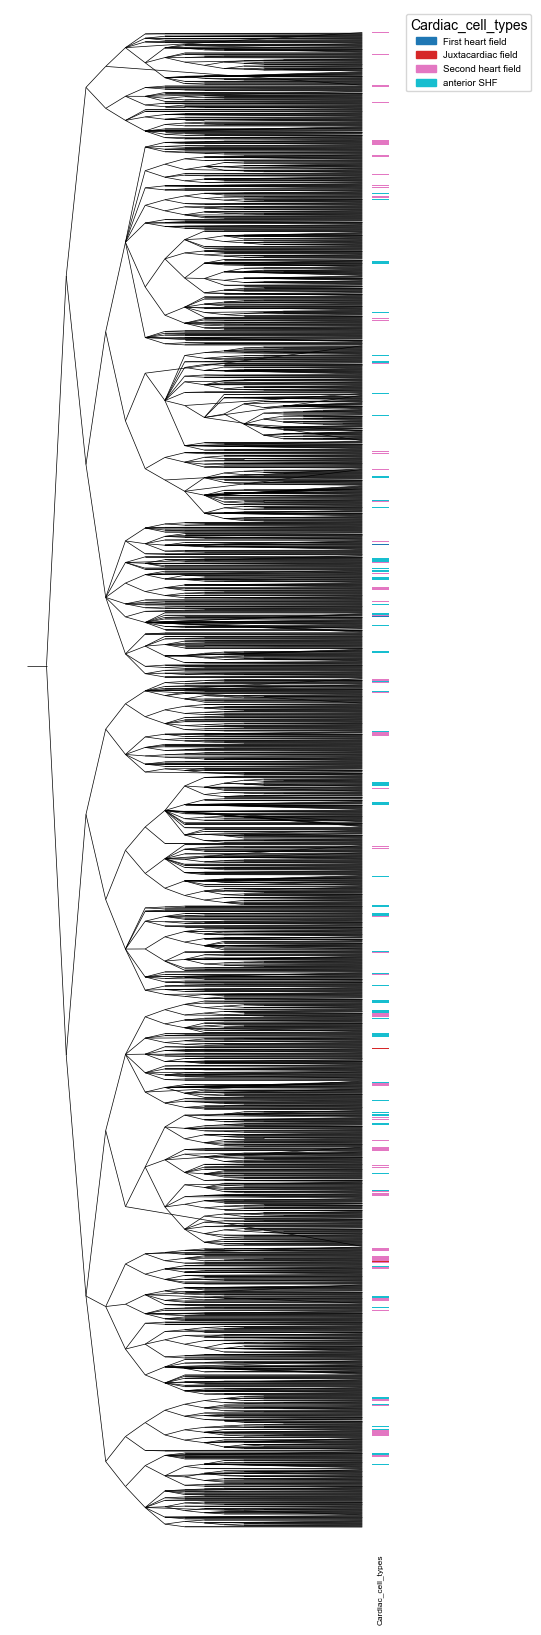

In [17]:
py.pl.branches(adata, depth_key="depth", angled_branches=True, extend_branches=True, tree="E8.0-R1-C1")
py.pl.annotation(adata, keys=["Cardiac_cell_types"], tree="E8.0-R1-C1")


In [13]:
import matplotlib.colors as mcolors
palette_template = mcolors.TABLEAU_COLORS

In [14]:
list(palette_template.values())

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

In [42]:

leaf_order = py.get.leaves(clone_tdata, tree=clone_key)
len(leaf_order)

2444

In [24]:
lca_depths

array([[ 9,  8,  7, ...,  1,  1,  1],
       [ 8,  9,  7, ...,  1,  1,  1],
       [ 7,  7, 12, ...,  1,  1,  1],
       ...,
       [ 1,  1,  1, ...,  8,  7,  5],
       [ 1,  1,  1, ...,  7,  8,  5],
       [ 1,  1,  1, ...,  5,  5,  6]], shape=(2444, 2444))

In [49]:
clone_key = "E8.5-R1-C1"
clone_tdata = adata[adata.obs["tree"] == clone_key].copy()
add_obs_to_tree(clone_tdata, keys=["Cardiac_cell_types", "germ_layer"])
py.pp.add_depth(clone_tdata)
py.tl.ancestral_states(clone_tdata, keys="Cardiac_cell_types", tree=clone_key, method="mode")
# override mixed internal nodes
flag_mixed_nodes(clone_tdata, clone_key, cell_type_key="Cardiac_cell_types")
# propagate to edges
add_node_attrs_to_edges(clone_tdata, keys=["Cardiac_cell_types", "germ_layer"])



# build palette: take your existing cell type colors and add mixed
import matplotlib.pyplot as plt
from matplotlib import gridspec
# get unique cell types present in this clone
cell_types = clone_tdata.obs["Cardiac_cell_types"].unique().tolist()
palette = dict(zip(cell_types, list(palette_template.values())[:len(cell_types)]))
palette['nan'] = 'gray'
palette["mixed"] = (0.6, 0.6, 0.6, 1.0)  # grey for mixed nodes

# Build an LCA distance matrix for the current clone tree
py.tl.tree_distance(clone_tdata, tree=clone_key, metric="lca", key_added="lca")
lca_depths = clone_tdata.obsp["lca_distances"]
if hasattr(lca_depths, "toarray"):
    lca_depths = lca_depths.toarray()

leaf_order = py.get.leaves(clone_tdata, tree=clone_key)
cell_types = clone_tdata.obs.loc[leaf_order, "Cardiac_cell_types"].astype(str).to_numpy()

valid_types = [ct for ct in np.unique(cell_types) if ct not in {"nan", "None", "", "<NA>"}]

# Slide a 5-leaf window through the leaves from top to bottom.
# For each window and each cell type present in that window, compute the
# common-ancestor depth of those leaves and place a point shifted by that depth
# from the window's midpoint position.
points = []
for start in range(0, len(leaf_order), 5):
    window_leaves = leaf_order[start:start + 5]
    if len(window_leaves) < 2:
        continue

    middle_pos = start + 2
    if middle_pos >= len(leaf_order):
        middle_pos = len(leaf_order) - 1

    for ct in valid_types:
        ct_leaves = [leaf for leaf in window_leaves if clone_tdata.obs.loc[leaf, "Cardiac_cell_types"] == ct]
        if len(ct_leaves) < 2:
            continue

        ct_idx = [clone_tdata.obs_names.get_loc(leaf) for leaf in ct_leaves]
        sub = lca_depths[np.ix_(ct_idx, ct_idx)]
        tri = np.triu_indices(len(ct_idx), k=1)
        pair_depths = sub[tri]
        ancestor_depth = float(np.min(pair_depths)) if len(pair_depths) > 0 else 0.0

        points.append((ancestor_depth, middle_pos, ct))


/scratch/local/jobs/51458753/ipykernel_3136766/2272128183.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


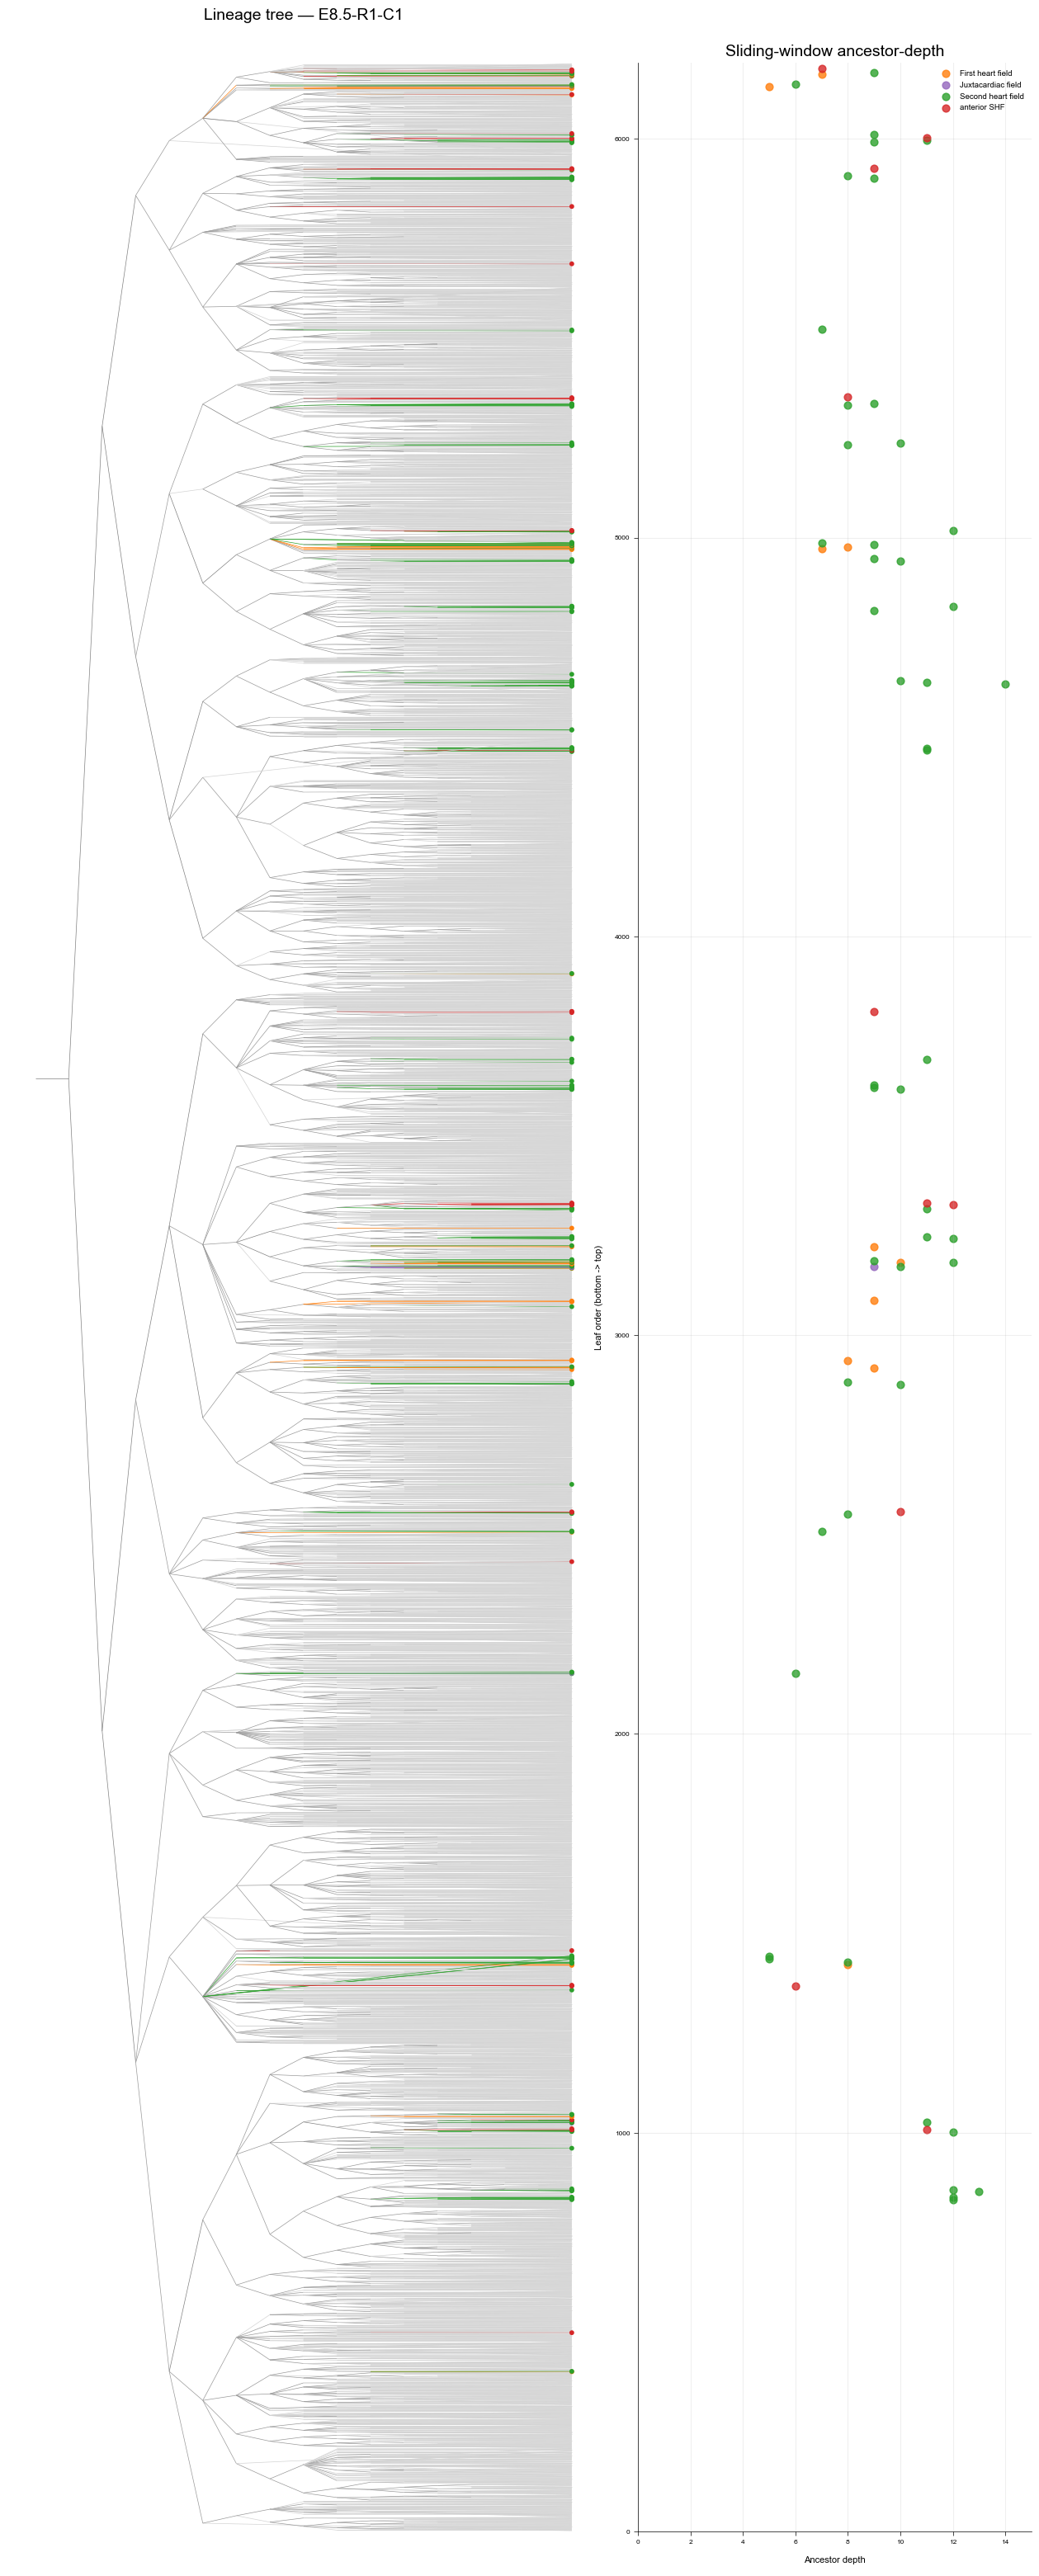

In [50]:

# Create a tree panel and a right-side point panel
fig = plt.figure(figsize=(16, 40))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.08)
ax_tree = fig.add_subplot(gs[0])

ax_points = fig.add_subplot(gs[1])

# 2. Get the current bounding box of the right plot
pos = ax_points.get_position()

# 3. Explicitly set your own upper and lower bounds!
# pos.x0 = current left edge, pos.width = current width
# Change 'bottom' and 'height' to whatever decimals you want (0.0 to 1.0)
new_bottom = 0.121 # Lower height limit (30% up from the bottom of the canvas)
new_height = 0.748 # Total height of the plot (50% of the canvas height)

ax_points.set_position([pos.x0, new_bottom, pos.width, new_height])



py.pl.branches(
    clone_tdata,
    depth_key="depth",
    color="Cardiac_cell_types",
    palette=palette,
    extend_branches=True,
    angled_branches=True,
    tree=clone_key,
    legend=False,
    ax=ax_tree,
)
py.pl.nodes(
    clone_tdata,
    color="Cardiac_cell_types",
    palette=palette,
    nodes="leaves",
    size=10,
    legend=False,
    tree=clone_key,
    ax=ax_tree,
)
ax_tree.set_title(f"Lineage tree — {clone_key}", fontsize=14)

for ct in valid_types:
    subset = [p for p in points if p[2] == ct]
    if not subset:
        continue
    xs = [p[0] for p in subset]
    ys = [p[1] for p in subset]
    ax_points.scatter(xs, ys, color=palette.get(ct, "black"), s=40, alpha=0.8, label=ct)

x_max = max([p[0] for p in points], default=1.0)
ax_points.set_xlim(0, x_max + 1)
ax_points.set_ylim(0, len(leaf_order) - 1)
ax_points.set_xlabel("Ancestor depth")
ax_points.set_ylabel("Leaf order (bottom -> top)")
ax_points.set_title("Sliding-window ancestor-depth", fontsize=14)
ax_points.grid(alpha=0.2)
ax_points.legend(loc="best", frameon=False)

plt.tight_layout()
plt.savefig(output_path_plot + "E8_5_R1_C1_tree_with_celltype_points.svg", bbox_inches="tight")
plt.show()